# Hardware health → allowable model depths

This notebook measures how well a **specific group of four physical qubits** can run circuits, then demonstrates how that measurement can restrict the anomaly detector's depth.

Mirror Randomized Benchmarking (**MRB**) sends random circuits through a forward-and-mirrored sequence. Each ideal circuit ends in a known bitstring. Hardware errors cause the measured answers to drift away from that target. We measure that drift across several circuit depths.

**Start here:** choose settings below, then run from the top. The default reads saved results; connecting to IBM and submitting a job are both disabled. Nothing trains the anomaly detector here.

The reusable algorithms live in `src/probes.py`, `src/execution.py`, and `src/controller.py`. The original implementation remains in `legacynotebook.ipynb`. This notebook contains orchestration, explanations, tables, and figures.

In [16]:
from pathlib import Path
from datetime import datetime, timezone
import json
import sys
import uuid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works when Jupyter starts in either the repository root or notebooks/.
REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "probes.py").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Open this notebook from inside the project repository.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import backend, execution, probes, controller

plt.rcParams.update({"figure.figsize": (9, 4), "font.size": 11})
print("Repository:", REPO_ROOT)

Repository: c:\Users\badir\OneDrive\Documents\QML\Team_03_QFF2026_uottawa


## 1. Choose what to do

- **`saved`**: analyze an existing `mrb_results.json`; no IBM connection is needed.
- **`new`**: generate and compile a fresh probe. Submission needs both hardware switches enabled.
- **`recover`**: retrieve the results of an already submitted job using its saved submission manifest. This needs a connection, but submits no new job.

For the first run, leave the switches off. Set `SAVED_RESULTS_PATH` to your saved result file when available. With no file, the notebook explains the protocol and skips measured analysis.

The refresh settings below create **12 logical circuits**: three depths × four random instances. Running identical logical circuits on two regions gives **24 physical circuits in one job**, or **6,144 shots** at 256 shots per circuit. The larger original benchmark used depths 0, 4, 8, 16, 32 and eight instances per depth.

Set `QML_RUN_DIR` to an anomaly experiment run containing `compiled_model_resources.json` to demonstrate the controller using actual compiled QML costs. Choose the loss budget yourself; it is a policy choice, not a learned detection threshold.

In [17]:
MODE = "saved"                       # "saved", "new", or "recover"
SAVED_RESULTS_PATH = REPO_ROOT / "results" / "mrb_20261008T031414Z_5f6bd2" / "mrb_results.json"  # e.g. REPO_ROOT / "results" / "mrb_run" / "mrb_results.json"
RECOVERY_MANIFEST_PATH = None           # ... / "submission.json"
CONNECT_TO_IBM = False
SUBMIT_QPU_JOB = False
BACKEND_NAME = "ibm_quebec"

REGIONS = {"0123": [0, 1, 2, 3], "6789": [6, 7, 8, 9]}
MRB_DEPTHS = [0, 8, 32]
INSTANCES = 4
SHOTS = 256
BASE_SEED = 50000
TRANSPILE_SEED = 42

RUN_BOOTSTRAP = True
BOOTSTRAP_REPEATS = 500                 # Increase to 5,000 for the final statistical report.
BOOTSTRAP_SEED = 42
CONFIDENCE = 0.95

QML_RUN_DIR = None
MAX_POLARIZATION_LOSS = None            # Example policy: 0.10 means at most 10% relative decay.
USE_BOOTSTRAP_LOWER_BOUND = True
SAVE_RESULTS = True

if MODE not in {"saved", "new", "recover"}:
    raise ValueError("MODE must be saved, new, or recover.")
if SUBMIT_QPU_JOB and (MODE != "new" or not CONNECT_TO_IBM):
    raise ValueError("New submission requires MODE='new' and CONNECT_TO_IBM=True.")
if MODE == "saved" and CONNECT_TO_IBM:
    raise ValueError("Saved analysis needs no connection; keep CONNECT_TO_IBM=False.")
if not 0 < CONFIDENCE < 1:
    raise ValueError("CONFIDENCE must lie between 0 and 1.")

def project_path(value):
    path = Path(value).expanduser()
    return path if path.is_absolute() else REPO_ROOT / path

print("Mode:", MODE, "| IBM connection:", CONNECT_TO_IBM, "| new submission:", SUBMIT_QPU_JOB)
print("Configured refresh:", len(MRB_DEPTHS) * INSTANCES * len(REGIONS), "circuits;",
      len(MRB_DEPTHS) * INSTANCES * len(REGIONS) * SHOTS, "shots")

Mode: new | IBM connection: True | new submission: True
Configured refresh: 24 circuits; 6144 shots


## 2. Check the protocol locally

This tiny check uses exact, noiseless simulation. It does **not** contact IBM or estimate hardware health. It verifies that one generated MRB circuit has a deterministic target, that perfect answers give polarization 1, and that uniformly random answers give polarization 0.

In the four-qubit formula, `h[k]` is the fraction of answers differing from the target in exactly `k` positions:

\[
S = \frac{256}{255}\sum_{k=0}^{4}(-1/2)^k h_k - \frac{1}{255}.
\]

**Success probability** only counts exact matches. **Polarization** uses all five distance bins. They are different statistics; individual polarization estimates can be negative.

In [18]:
example_circuit = probes.make_mrb_circuit_v2(depth=8, seed=BASE_SEED)
example_target, example_probability = probes.ideal_target(example_circuit)
assert example_probability > 0.999999
perfect_S, _ = probes.effective_polarization({example_target: 256}, example_target)
uniform_counts = {format(i, "04b"): 16 for i in range(16)}
uniform_S, _ = probes.effective_polarization(uniform_counts, example_target)
assert np.isclose(perfect_S, 1.0) and np.isclose(uniform_S, 0.0)
print("Local protocol check passed. Example ideal target:", example_target)
print("These checks are not hardware measurements.")

Local protocol check passed. Example ideal target: 1011
These checks are not hardware measurements.


## 3. Load saved results or prepare a hardware run

A saved result contains `backend`, `recorded_at_utc`, and a list of `records`. Each record identifies its region, physical qubits, depth, random instance, target, compiled two-qubit gate count, counts, success probability, and polarization.

Keep each probe run separate. Combining old and new runs can hide hardware drift. A timestamp records when the probe was recorded or submitted; it does not prove that the hardware is still in the same condition.

New and recovered jobs save an ordered manifest so each returned result can be matched to the correct circuit. Recovery uses that original order; it never regenerates circuits from today's settings.

In [19]:
probe_payload = None
probe_records = []
submission = None
physical_records = []
manifest = []
service = qpu = job = None
probe_run_dir = None

if MODE == "saved":
    if SAVED_RESULTS_PATH is None:
        print("No saved results selected. Measured analysis will be skipped.")
    else:
        source_path = project_path(SAVED_RESULTS_PATH)
        probe_payload = json.loads(source_path.read_text(encoding="utf-8"))
        probe_records = probe_payload["records"]
        print("Loaded:", source_path)
elif MODE == "recover":
    if RECOVERY_MANIFEST_PATH is None:
        raise ValueError("Set RECOVERY_MANIFEST_PATH to the original submission.json.")
    submission = json.loads(project_path(RECOVERY_MANIFEST_PATH).read_text(encoding="utf-8"))
    manifest = submission["circuit_metadata"]
    if submission["config"]["backend"] != BACKEND_NAME:
        raise ValueError("Recovery manifest backend differs from BACKEND_NAME.")
    print("Existing job:", submission["job_id"], "| circuits:", len(manifest))

### Hardware connection — explicit opt-in

This cell does nothing unless `CONNECT_TO_IBM=True`. When you run it yourself, `backend.connect_backend()` loads the token from your external `~/.qff26/.env` through python-dotenv. The token is never displayed or saved in this notebook.

Compilation chooses the physical layout and checks the qubit chain. MRB uses optimization level **0** to preserve the benchmark workload. The anomaly model uses its own optimization level **1** templates in the other notebook.

In [20]:
backend_metadata = None
if MODE in {"new", "recover"} and CONNECT_TO_IBM:
    service, qpu = backend.connect_backend(BACKEND_NAME)
    backend_metadata = backend.get_backend_metadata(qpu)
    print("Connected backend:", backend_metadata["backend"])
else:
    print("IBM connection skipped.")

if MODE == "new" and qpu is not None:
    logical_records = probes.generate_mrb_records(
        MRB_DEPTHS, instances=INSTANCES, base_seed=BASE_SEED
    )
    physical_records = probes.prepare_mrb_records(
        logical_records, qpu, REGIONS, seed_transpiler=TRANSPILE_SEED
    )
    manifest = probes.build_mrb_manifest(physical_records)
    display(pd.DataFrame(manifest)[
        ["result_index", "region", "depth", "instance", "target",
         "transpiled_depth", "two_qubit_gates"]
    ])
    print("Compiled", len(manifest), "circuits. No job has been submitted by this cell.")
elif MODE == "new":
    print("Enable CONNECT_TO_IBM to compile against the real backend.")

qiskit_runtime_service._discover_account:WARNING:2026-10-07 23:14:05,132: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-10-07 23:14:12,643: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon UOttawa Oct 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-10-07 23:14:12,644: Using instance: Hackathon UOttawa Oct 2026, plan: on-prem


Connected backend: ibm_quebec


,result_index,region,depth,instance,target,transpiled_depth,two_qubit_gates
0,0,0123,0,0,1011,15,0
1,1,0123,0,1,1100,17,0
2,2,0123,0,2,0000,15,0
3,3,0123,0,3,1010,12,0
4,4,0123,8,0,0110,83,12
5,5,0123,8,1,0000,83,8
6,6,0123,8,2,0101,82,12
7,7,0123,8,3,0001,80,8
8,8,0123,32,0,0111,285,26
9,9,0123,32,1,1010,290,36


Compiled 24 circuits. No job has been submitted by this cell.


### Submit once, or recover an existing job

The new-job cell makes **one submission containing both regions**. The same logical circuits are used in both regions, enabling a fairer comparison.

The manifest is saved immediately after submission, before waiting for results. Keep its path and job ID. If your kernel restarts, switch to `recover`; do not resubmit just to retrieve results.

The current kernel refuses a second new submission. After a restart that guard is lost. Changing settings without restarting and running from the top can also leave stale state; for a different experiment, restart and review the settings first.

In [21]:
if MODE == "new" and SUBMIT_QPU_JOB:
    if globals().get("_submitted_probe_job_id") is not None:
        raise RuntimeError("Already submitted in this kernel. Recover that job instead.")
    if not physical_records or qpu is None:
        raise RuntimeError("Connect and compile the probe before submitting.")
    if not SAVE_RESULTS:
        raise ValueError("Keep SAVE_RESULTS=True for hardware jobs so the manifest is preserved.")
    run_name = "mrb_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:6]
    probe_run_dir = REPO_ROOT / "results" / run_name
    # Establish a writable destination before spending QPU time.
    probe_run_dir.mkdir(parents=True, exist_ok=False)
    sampler = execution.create_sampler(qpu)
    job = execution.submit_circuits(
        sampler, [record["circuit"] for record in physical_records], shots=SHOTS
    )
    _submitted_probe_job_id = job.job_id()
    print("Submitted job:", _submitted_probe_job_id)
    print("Manifest destination:", probe_run_dir / "submission.json")
    execution.save_submission_record(
        probe_run_dir / "submission.json", _submitted_probe_job_id,
        shots=SHOTS, circuit_metadata=manifest,
        config={"backend": BACKEND_NAME, "regions": REGIONS, "depths": MRB_DEPTHS,
                "instances": INSTANCES, "base_seed": BASE_SEED,
                "seed_rule": "base_seed + depth*100 + instance",
                "optimization_level": 0, "seed_transpiler": TRANSPILE_SEED,
                "backend_metadata": backend_metadata},
    )
    submission = json.loads((probe_run_dir / "submission.json").read_text(encoding="utf-8"))
elif MODE == "recover" and service is not None:
    job = execution.retrieve_job(service, submission["job_id"])
    print("Retrieved existing job; no new submission.")
else:
    print("Submission/retrieval skipped.")

Submitted job: db3gl204qg6s73c0mi50
Manifest destination: c:\Users\badir\OneDrive\Documents\QML\Team_03_QFF2026_uottawa\results\mrb_20261008T031414Z_5f6bd2\submission.json


In [22]:
if job is not None:
    # This waits for the existing job and may take time in the IBM queue.
    raw_result = job.result()
    probe_records = probes.process_mrb_results(raw_result, manifest)
    probe_payload = {
        "backend": submission["config"]["backend"],
        "recorded_at_utc": submission["recorded_at_utc"],
        "timestamp_kind": "submission",
        "retrieved_at_utc": datetime.now(timezone.utc).isoformat(),
        "job_id": submission["job_id"],
        "config": submission["config"],
        "records": probe_records,
    }
    print("Decoded", len(probe_records), "circuit results.")
else:
    print("No hardware result retrieval requested.")

Decoded 24 circuit results.


## 4. Validate and preserve the measurements

Save the raw counts **before** fitting or plotting. A failed fit should not lose an expensive hardware result.

Saved analysis writes a new analysis directory, preserving its source. Recovery also writes a new directory while retaining the original job ID and submission timestamp. Re-running this cell uses the same analysis directory within the current run.

The exported `mrb_results.json` is the file to set as `MRB_RESULTS_PATH` in `anomaly_experiment.ipynb`. Its timestamp stays attached to the original probe, even if you analyze it days later.

In [23]:
def json_default(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Cannot serialize {type(value).__name__}")

def save_json(name, value):
    if SAVE_RESULTS and probe_run_dir is not None:
        (probe_run_dir / name).write_text(
            json.dumps(value, indent=2, default=json_default, allow_nan=False) + "\n",
            encoding="utf-8",
        )

if probe_payload is not None:
    if probe_payload["backend"] != BACKEND_NAME:
        raise ValueError("Saved probe backend differs from BACKEND_NAME.")
    stamp = datetime.fromisoformat(probe_payload["recorded_at_utc"].replace("Z", "+00:00"))
    if stamp.tzinfo is None:
        raise ValueError("Probe timestamp needs a timezone; do not guess its measurement date.")
    if not probe_records:
        raise ValueError("The selected result has no circuit records.")
    seen = set()
    layouts = {}
    for record in probe_records:
        identity = (record["region"], record["depth"], record["instance"])
        if identity in seen:
            raise ValueError("Duplicate region/depth/instance. Supply one probe run.")
        seen.add(identity)
        layout = tuple(record["physical_qubits"])
        if record["region"] in layouts and layouts[record["region"]] != layout:
            raise ValueError("A region changed layout within this run.")
        layouts[record["region"]] = layout
        if len(layout) != 4 or len(set(layout)) != 4:
            raise ValueError("Expected four distinct physical qubits.")
        if not np.isfinite(record["polarization"]):
            raise ValueError("Invalid polarization.")
        if not 0 <= record["success_probability"] <= 1:
            raise ValueError("Invalid success probability.")
        if "counts" in record:
            S, h = probes.effective_polarization(record["counts"], record["target"])
            if not np.isclose(S, record["polarization"]):
                raise ValueError("Stored polarization disagrees with the raw counts.")
            counts = record["counts"]
            success = counts.get(record["target"], 0) / sum(counts.values())
            if not np.isclose(success, record["success_probability"]):
                raise ValueError("Stored success probability disagrees with the raw counts.")
    if SAVE_RESULTS and probe_run_dir is None:
        run_name = "mrb_analysis_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:6]
        probe_run_dir = REPO_ROOT / "results" / run_name
        probe_run_dir.mkdir(parents=True, exist_ok=False)
    save_json("mrb_results.json", probe_payload)
    save_json("analysis_config.json", {
        "mode": MODE, "source": str(SAVED_RESULTS_PATH) if MODE == "saved" else str(RECOVERY_MANIFEST_PATH),
        "analyzed_at_utc": datetime.now(timezone.utc).isoformat(),
        "run_bootstrap": RUN_BOOTSTRAP, "bootstrap_repeats": BOOTSTRAP_REPEATS,
        "bootstrap_seed": BOOTSTRAP_SEED, "confidence": CONFIDENCE,
        "max_polarization_loss": MAX_POLARIZATION_LOSS,
        "use_bootstrap_lower_bound": USE_BOOTSTRAP_LOWER_BOUND,
        "qml_run_dir": None if QML_RUN_DIR is None else str(QML_RUN_DIR),
    })
    print("Backend:", probe_payload["backend"])
    print("Original probe timestamp:", probe_payload["recorded_at_utc"],
          "| kind:", probe_payload.get("timestamp_kind", "unspecified"))
    print("Region layouts:", layouts)
    print("Export directory:", probe_run_dir if SAVE_RESULTS else "saving disabled")
else:
    print("No measured data to validate or export.")

Backend: ibm_quebec
Original probe timestamp: 2026-10-08T03:14:16.058170+00:00 | kind: submission
Region layouts: {'0123': (0, 1, 2, 3), '6789': (6, 7, 8, 9)}
Export directory: c:\Users\badir\OneDrive\Documents\QML\Team_03_QFF2026_uottawa\results\mrb_20261008T031414Z_5f6bd2


## 5. Compare regions and fit the decay

First group the results by physical region and MRB depth. We average over the random circuits at each depth.

Then fit \(\bar S(d)=A p^d\). **\(p\)** measures how much polarization is retained per MRB depth step: closer to 1 means slower decay. **\(A\)** captures the fitted starting amplitude. For four qubits we report \(r_\Omega=(255/256)(1-p)\).

\(r_\Omega\) is an effective MRB layer-error estimate under the decay model. It is not an anomaly detector error rate or an error probability per native gate. Inspect the plotted fit before trusting its summary, particularly with only three depths and four circuits per depth.

Error bars below show **spread among circuits** (population standard deviation), not confidence intervals. A better point estimate does not by itself establish a statistically significant difference.

In [24]:
summary = pd.DataFrame(probes.summarize_mrb(probe_records))
fits = {}
fit_failures = {}
if probe_records:
    display(summary.sort_values(["region", "depth"]).reset_index(drop=True))
    for region in sorted(summary["region"].unique()):
        depths = sorted(summary.loc[summary["region"] == region, "depth"].unique().tolist())
        try:
            fits[region] = probes.fit_mrb_region(probe_records, region, depths)
        except (ValueError, RuntimeError) as exc:
            fit_failures[region] = str(exc)
    fit_table = pd.DataFrame([
        {"region": region, "A": fit["A"], "p": fit["p"], "r_omega": fit["r_omega"]}
        for region, fit in fits.items()
    ])
    display(fit_table)
    if fit_failures:
        print("Fits that could not be used:", fit_failures)
    save_json("mrb_fits.json", {"fits": fits, "failures": fit_failures})
    if SAVE_RESULTS:
        summary.to_csv(probe_run_dir / "mrb_summary.csv", index=False)
        fit_table.to_csv(probe_run_dir / "mrb_fit_summary.csv", index=False)
else:
    print("Region comparison skipped: no measured records.")

,region,depth,instances,success_probability_mean,success_probability_std,polarization_mean,polarization_std
0,0123,0,4,0.968750,0.014352,0.953676,0.021849
1,0123,8,4,0.897461,0.016659,0.859559,0.028771
2,0123,32,4,0.731445,0.040911,0.702022,0.038176
3,6789,0,4,0.905273,0.012158,0.865441,0.019440
4,6789,8,4,0.570312,0.203837,0.463603,0.254402
5,6789,32,4,0.136719,0.071709,0.042096,0.104301


,region,A,p,r_omega
0,0123,0.943212,0.990605,0.009359
1,6789,0.870052,0.921341,0.078351


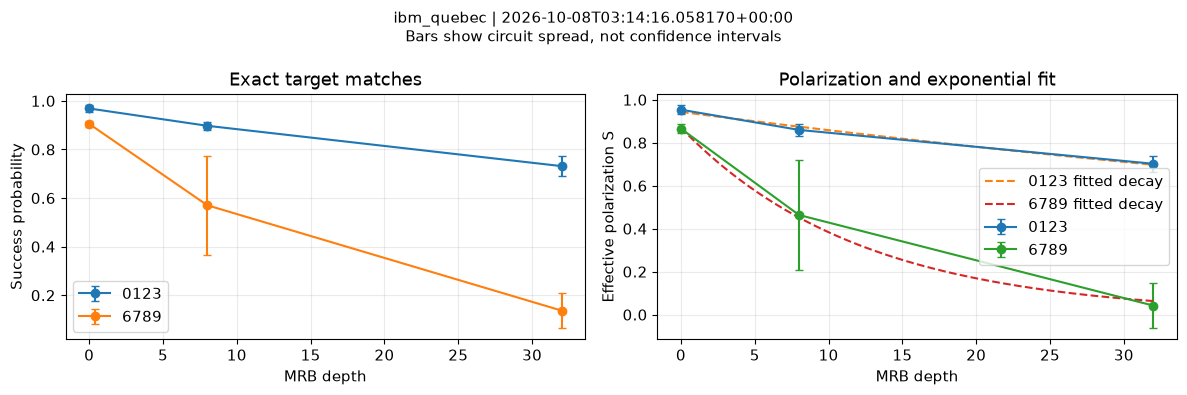

In [25]:
def save_figure(fig, name):
    if SAVE_RESULTS and probe_run_dir is not None:
        directory = probe_run_dir / "figures"
        directory.mkdir(exist_ok=True)
        fig.savefig(directory / f"{name}.png", dpi=300, bbox_inches="tight")
        fig.savefig(directory / f"{name}.pdf", bbox_inches="tight")

if probe_records:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for region, group in summary.groupby("region"):
        group = group.sort_values("depth")
        axes[0].errorbar(group["depth"], group["success_probability_mean"],
                         yerr=group["success_probability_std"], marker="o", capsize=3, label=region)
        axes[1].errorbar(group["depth"], group["polarization_mean"],
                         yerr=group["polarization_std"], marker="o", capsize=3, label=region)
        if region in fits:
            d = np.linspace(group["depth"].min(), group["depth"].max(), 200)
            axes[1].plot(d, probes.decay_model(d, fits[region]["A"], fits[region]["p"]),
                         linestyle="--", label=f"{region} fitted decay")
    axes[0].set(title="Exact target matches", xlabel="MRB depth", ylabel="Success probability")
    axes[1].set(title="Polarization and exponential fit", xlabel="MRB depth", ylabel="Effective polarization S")
    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend()
    fig.suptitle(f"{probe_payload['backend']} | {probe_payload['recorded_at_utc']}\n"
                 "Bars show circuit spread, not confidence intervals", fontsize=11)
    fig.tight_layout()
    save_figure(fig, "mrb_region_comparison")
    plt.show()

## 6. Estimate uncertainty without another QPU job

Bootstrap analysis repeatedly resamples the **circuits within each depth** and refits the decay. The interval describes uncertainty from the limited collection of random circuits. It does not include future hardware drift, all shot noise effects, or uncertainty in the controller's cost mapping.

This cell uses 500 repetitions for a quick run. For final reporting you can increase it to 5,000. We record how many fits succeeded; failed fits are omitted by the existing helper. With only four circuits per depth, treat intervals cautiously.

For the controller we can use a lower bound on \(p\), which assumes less polarization retention than the point estimate. We cap that bound at the point estimate so it cannot make the policy more permissive.

In [26]:
bootstrap_samples = {}
bootstrap_rows = []
bootstrap_failures = {}
p_lower_bounds = {}
tail = (1 - CONFIDENCE) / 2

if RUN_BOOTSTRAP and fits:
    for region, fit in fits.items():
        try:
            samples = probes.bootstrap_mrb_region(
                probe_records, region, [int(d) for d in fit["depths"]],
                n_bootstrap=BOOTSTRAP_REPEATS, seed=BOOTSTRAP_SEED,
            )
            bootstrap_samples[region] = samples
            p_interval = np.quantile(samples["p"], [tail, 1 - tail])
            r_interval = np.quantile(samples["r_omega"], [tail, 1 - tail])
            p_lower_bounds[region] = min(fit["p"], float(p_interval[0]))
            bootstrap_rows.append({
                "region": region, "p": fit["p"], "p_lower": float(p_interval[0]),
                "p_upper": float(p_interval[1]), "r_omega": fit["r_omega"],
                "r_omega_lower": float(r_interval[0]), "r_omega_upper": float(r_interval[1]),
                "confidence": CONFIDENCE, "requested_fits": BOOTSTRAP_REPEATS,
                "successful_fits": len(samples["p"]),
                "controller_p_lower": p_lower_bounds[region],
            })
        except (ValueError, RuntimeError) as exc:
            bootstrap_failures[region] = str(exc)
    bootstrap_table = pd.DataFrame(bootstrap_rows)
    display(bootstrap_table)
    if bootstrap_failures:
        print("Bootstrap failures:", bootstrap_failures)
    save_json("mrb_bootstrap.json", {
        "intervals": bootstrap_rows, "failures": bootstrap_failures,
        "samples": bootstrap_samples,
    })
    if SAVE_RESULTS:
        bootstrap_table.to_csv(probe_run_dir / "mrb_bootstrap_intervals.csv", index=False)
else:
    print("Bootstrap skipped.")

,region,p,p_lower,p_upper,r_omega,r_omega_lower,r_omega_upper,confidence,requested_fits,successful_fits,controller_p_lower
0,0123,0.990605,0.988865,0.992409,0.009359,0.007561,0.011092,0.95,500,500,0.988865
1,6789,0.921341,0.841469,0.946247,0.078351,0.053543,0.157912,0.95,500,500,0.841469


## 7. Convert hardware health into a model-depth constraint

MRB depth and QML depth mean different things. **Do not directly compare MRB depth 8 to QML layer 8.**

Our controller uses compiled two-qubit gate counts as a practical bridge:

1. Fit the mean MRB gate cost: \(N_{2Q}(d)=b+md\).
2. Map a compiled QML circuit to equivalent MRB depth: \(d_{eq}=N_{2Q}(QML)/m\).
3. Estimate relative polarization loss: \(1-p^{d_{eq}}\).
4. Allow a model depth only if that loss is within your budget and its equivalent depth is within the measured MRB range.

The fitted intercept is reported, but is **not** subtracted from QML cost. The amplitude \(A\) cancels in relative retention; this policy therefore excludes starting-amplitude/readout loss.

**This is an explicit heuristic.** Equal two-qubit gate counts do not guarantee equal noise. Gate types, durations, one-qubit operations, scheduling, coherent errors, and drift still matter. The loss proxy is neither classification error nor a certified hardware error bound.

Load actual compiled resources from the anomaly notebook. We do not invent gate costs for missing models. The qubit order and backend must match. A fresh probe should be used for deployment.

In [27]:
calibrations = {}
for region in fits:
    try:
        calibrations[region] = controller.calibrate_mrb_cost(probe_records, region)
    except ValueError as exc:
        print(f"Cost calibration unavailable for {region}: {exc}")
if calibrations:
    display(pd.DataFrame([
        {"region": region, "gates_per_MRB_depth": item["two_qubit_gates_per_mrb_depth"],
         "intercept": item["intercept"], "r_squared": item["r_squared"]}
        for region, item in calibrations.items()
    ]))
    save_json("mrb_cost_calibration.json", calibrations)

,region,gates_per_MRB_depth,intercept,r_squared
0,0123,1.03125,0.75,0.997253
1,6789,1.03125,0.75,0.997253


In [28]:
qml_resources = {}
qml_validation = None
qml_directory = None
if QML_RUN_DIR is not None:
    qml_directory = project_path(QML_RUN_DIR)
    qml_backend = json.loads((qml_directory / "backend_metadata.json").read_text(encoding="utf-8"))
    if qml_backend["backend"] != BACKEND_NAME:
        raise ValueError("Compiled QML resources come from a different backend.")
    resource_payload = json.loads(
        (qml_directory / "compiled_model_resources.json").read_text(encoding="utf-8")
    )
    qml_resources = {
        region: {int(L): resource for L, resource in depths.items()}
        for region, depths in resource_payload.items()
    }
    validation_path = qml_directory / "hardware_metrics.csv"
    if validation_path.is_file():
        qml_validation = pd.read_csv(validation_path, dtype={"region": str})
        print("Using hardware validation metrics from:", validation_path)
    else:
        print("No hardware_metrics.csv yet. We can constrain depths, but will not choose a winner.")
else:
    print("Set QML_RUN_DIR to use the anomaly experiment's compiled resources.")

Set QML_RUN_DIR to use the anomaly experiment's compiled resources.


In [29]:
constraints_by_region = {}
selections = {}

if fits and qml_resources:
    if MAX_POLARIZATION_LOSS is None:
        raise ValueError("Choose MAX_POLARIZATION_LOSS explicitly before running the controller.")
    for region in sorted(set(calibrations) & set(qml_resources)):
        if USE_BOOTSTRAP_LOWER_BOUND and region not in p_lower_bounds:
            print(f"Skipping {region}: a bootstrap lower bound was requested but is unavailable.")
            continue
        constraints = controller.constrain_depths(
            fits[region], calibrations[region], qml_resources[region],
            max_polarization_loss=MAX_POLARIZATION_LOSS,
            p_lower=p_lower_bounds[region] if USE_BOOTSTRAP_LOWER_BOUND else None,
            allow_extrapolation=False,
        )
        constraints_by_region[region] = constraints
        print(f"Region {region}: allowed depths {constraints['allowed_depths']} "
              f"| p used {constraints['p_used']:.6f}")
        display(pd.DataFrame(constraints["depth_decisions"]))
        if qml_validation is not None:
            selections[region] = controller.select_depth(constraints, qml_validation)
            print("Validation-based choice:", selections[region])
    save_json("controller_decisions.json", {
        "probe_job_id": probe_payload.get("job_id"),
        "probe_recorded_at_utc": probe_payload["recorded_at_utc"],
        "qml_run_dir": str(qml_directory),
        "constraints": constraints_by_region, "selections": selections,
    })
else:
    print("Controller skipped: requires usable measured fits and compiled QML resources.")

Controller skipped: requires usable measured fits and compiled QML resources.


### Which allowed depth should we deploy?

Hardware health determines **which depths we consider allowable**. Validation determines **which allowable depth performs best**.

The existing selector chooses the highest ROC-AUC among allowed depths, breaking a tie in favor of the shallower model. It does not automatically choose the deepest allowed circuit. If no depth is allowed, it returns no deployment choice; it does not silently fall back to L1.

The metrics file must compare the same model family and the same validation samples across depths. A CSV alone cannot verify that experimental provenance; use the matching anomaly run's saved config and samples. Test-set results should not be used to choose depth.

When passing this probe to the anomaly notebook, that notebook currently uses the fitted **point estimate** of \(p\). This notebook optionally uses the bootstrap lower bound, so decisions can differ. Report which policy produced your final result.

In [30]:
if constraints_by_region:
    fig, ax = plt.subplots(figsize=(9, 4))
    for region, constraints in constraints_by_region.items():
        rows = constraints["depth_decisions"]
        ax.plot([r["L"] for r in rows], [r["predicted_polarization_loss"] for r in rows],
                marker="o", label=f"{region} ({constraints['p_source']})")
        rejected = [r for r in rows if not r["allowed"]]
        ax.scatter([r["L"] for r in rejected],
                   [r["predicted_polarization_loss"] for r in rejected],
                   marker="x", s=90)
    ax.axhline(MAX_POLARIZATION_LOSS, color="black", linestyle="--", label="Chosen loss budget")
    ax.set(title="Hardware constraint on compiled model depths",
           xlabel="QML depth L", ylabel="Relative polarization-loss proxy")
    ax.set_xticks(sorted({r["L"] for c in constraints_by_region.values() for r in c["depth_decisions"]}))
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    save_figure(fig, "hardware_depth_constraint")
    plt.show()

## 8. Handoff and presentation checkpoint

After a successful run, the result directory contains:

| File | What it records |
|---|---|
| `submission.json` (new jobs) | Job ID, exact circuit order, original submission timestamp, settings |
| `mrb_results.json` | Backend, original timestamp, per-circuit counts, target, compiled cost, measured statistics |
| `analysis_config.json` | Analysis settings and source paths |
| `mrb_summary.csv`, `mrb_fit_summary.csv`, `mrb_fits.json` | Region/depth summaries and decay fits |
| `mrb_bootstrap.json`, `mrb_bootstrap_intervals.csv` | Resampled fits and intervals, if enabled |
| `mrb_cost_calibration.json` | Gate-count bridge between MRB and QML |
| `controller_decisions.json` | Budget, allowed depths, and validation-based selections, when inputs exist |
| `figures/*.png`, `figures/*.pdf` | Presentation-ready region and controller figures |

For the anomaly notebook, set `MRB_RESULTS_PATH` to the exported `mrb_results.json` and explicitly choose `MAX_POLARIZATION_LOSS`.

A defensible final demonstration shows **measured MRB decay**, **compiled model costs**, **the declared hardware policy**, and **validation performance** separately. Do not label noiseless protocol checks as hardware results, or an allowable depth as proof of detection quality.

In [31]:
print("Measured circuit records:", len(probe_records))
print("Usable fitted regions:", list(fits))
print("Regions with controller decisions:", list(constraints_by_region))
if probe_run_dir is not None and SAVE_RESULTS:
    print("Saved probe for anomaly_experiment.ipynb:")
    print(probe_run_dir / "mrb_results.json")
else:
    print("No results were written.")
if selections:
    display(pd.DataFrame(selections.values()))

Measured circuit records: 24
Usable fitted regions: ['0123', '6789']
Regions with controller decisions: []
Saved probe for anomaly_experiment.ipynb:
c:\Users\badir\OneDrive\Documents\QML\Team_03_QFF2026_uottawa\results\mrb_20261008T031414Z_5f6bd2\mrb_results.json


## Where this workflow came from

Cell locations below refer to the one-based cell order documented in the preserved legacy implementation.

- **Legacy cells C7–C17:** random layers, MRB circuits, ideal target calculation. These algorithms are now called through `probes.py`.
- **C21–C37:** physical-region compilation, manifest, Runtime submission, result decoding. The notebook calls `probes.py` and the shared `execution.py` infrastructure.
- **C39–C48:** Hamming-distance distribution, polarization, grouping, and exponential decay fit.
- **C50:** circuit-resampling bootstrap.
- **The later refresh experiment:** three depths, four instances, 256 shots, and identical circuits on both regions.

The extracted generator uses `base_seed + depth*100 + instance`. The teammate's refresh used sequential seeds; the new refresh matches its protocol and scale, **not its exact random circuits**. Load the original saved records to analyze that original job.

The extracted fit bounds are \(0\le A\le1.5\), \(0\le p\le1\). Some later exploratory cells used an amplitude ceiling of 1.2. The summary helper uses population standard deviation; later notebook tables sometimes used sample standard deviation. Those choices can change numerical comparisons.

**New orchestration here:** explicit hardware switches, saved-result loading, existing-job recovery, validation of saved counts, persistent analysis artifacts, presentation figures, and the separate controller demonstration. The controller itself is new project logic in `controller.py`, not an algorithm extracted from the historical notebook.